# Experiments Notebook

This notebook records the model experiments, comparison tables, and evaluation results for the Intelligent Reading Comprehension and Quiz Generation System.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Split Verification

In [2]:
train = pd.read_csv("../data/processed/train.csv")
dev = pd.read_csv("../data/processed/dev.csv")
test = pd.read_csv("../data/processed/test.csv")

total = len(train) + len(dev) + len(test)

split_df = pd.DataFrame({
    "Split": ["Train", "Dev", "Test"],
    "Rows": [len(train), len(dev), len(test)],
    "Percentage": [
        round(len(train) / total * 100, 2),
        round(len(dev) / total * 100, 2),
        round(len(test) / total * 100, 2)
    ]
})

split_df

,Split,Rows,Percentage
0,Train,70292,80.0
1,Dev,8787,10.0
2,Test,8787,10.0


## Answer Label Distribution

This checks whether the answer labels A, B, C, and D are balanced after splitting.

In [3]:
label_dist = pd.DataFrame({
    "Train": train["answer"].value_counts(),
    "Dev": dev["answer"].value_counts(),
    "Test": test["answer"].value_counts()
}).fillna(0)

label_dist

,Train,Dev,Test
answer,,,
C,19112,2390,2389
B,18181,2273,2272
D,17682,2210,2211
A,15317,1914,1915


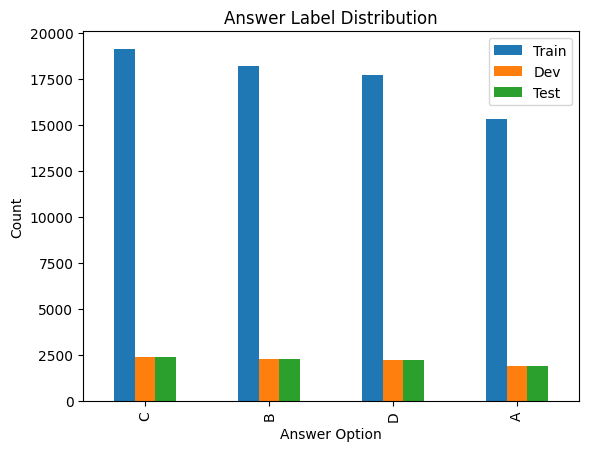

In [4]:
label_dist.plot(kind="bar")
plt.title("Answer Label Distribution")
plt.xlabel("Answer Option")
plt.ylabel("Count")
plt.show()

## Model A Experiments

In [5]:
model_a_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Hard Voting Ensemble",
        "K-Means",
        "GMM",
        "Label Propagation",
        "Random Forest Question Ranker"
    ],
    "Accuracy": [
        0.5148,
        0.5145,
        0.5153,
        "-",
        "-",
        0.7913,
        1.0000
    ],
    "Precision": [
        0.2580,
        0.2583,
        0.2582,
        "-",
        "-",
        "-",
        1.0000
    ],
    "Recall": [
        0.5017,
        0.5035,
        0.5013,
        "-",
        "-",
        "-",
        1.0000
    ],
    "Macro F1": [
        0.4784,
        0.4785,
        0.4788,
        "-",
        "-",
        0.4418,
        1.0000
    ],
    "Other Metric": [
        "-",
        "-",
        "-",
        "Silhouette: 0.0182, Purity: 0.7913",
        "Silhouette: 0.0142, Purity: 0.7913",
        "-",
        "-"
    ]
})

model_a_results

,Model,Accuracy,Precision,Recall,Macro F1,Other Metric
0,Logistic Regression,0.5148,0.258,0.5017,0.4784,-
1,SVM,0.5145,0.2583,0.5035,0.4785,-
2,Hard Voting Ensemble,0.5153,0.2582,0.5013,0.4788,-
3,K-Means,-,-,-,-,"Silhouette: 0.0182, Purity: 0.7913"
4,GMM,-,-,-,-,"Silhouette: 0.0142, Purity: 0.7913"
5,Label Propagation,0.7913,-,-,0.4418,-
6,Random Forest Question Ranker,1.0,1.0,1.0,1.0,-


## Model B Experiments

In [6]:
model_b_results = pd.DataFrame({
    "Task": [
        "Distractor Ranker"
    ],
    "Accuracy": [
        0.5147
    ],
    "Precision": [
        0.7570
    ],
    "Recall": [
        0.5199
    ],
    "Macro F1": [
        0.4780
    ]
})

model_b_results

,Task,Accuracy,Precision,Recall,Macro F1
0,Distractor Ranker,0.5147,0.757,0.5199,0.478


## Notes


The models were trained using fixed classical ML hyperparameters.  
Class imbalance was handled using class_weight="balanced in Logistic Regression, SVM, and Random Forest.
